# Import Libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Models
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from xgboost import XGBRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')



# Load and Parse Dataset

In [25]:


# Load dataset
df = pd.read_csv(
    "housepower.csv",
    sep=",",
    na_values=['?'],
    low_memory=False
)

# Convert time column to datetime
df['datetime'] = pd.to_datetime(df['time'])

# Set datetime index
df.set_index('datetime', inplace=True)

# Convert target column
df['global_active_power'] = pd.to_numeric(df['global_active_power'], errors='coerce')

# Keep only required column
df = df[['global_active_power']].dropna()

# Resample hourly
df_hourly = df.resample('H').mean()

# Feature engineering
df_feat = df_hourly.copy()

df_feat['hour'] = df_feat.index.hour
df_feat['day'] = df_feat.index.day
df_feat['month'] = df_feat.index.month
df_feat['weekday'] = df_feat.index.weekday

df_feat['is_weekend'] = (df_feat['weekday'] >= 5).astype(int)

df_feat.head()


,global_active_power,hour,day,month,weekday,is_weekend
datetime,,,,,,
2026-02-19 00:00:00,0.780775,0,19,2,3,0
2026-02-19 01:00:00,0.634853,1,19,2,3,0
2026-02-19 02:00:00,0.539581,2,19,2,3,0
2026-02-19 03:00:00,0.515721,3,19,2,3,0
2026-02-19 04:00:00,0.488086,4,19,2,3,0


# Resample Time Series (Hourly)

In [26]:
df_hourly = df.resample('H').mean()

df_hourly.head()


,global_active_power
datetime,
2026-02-19 00:00:00,0.780775
2026-02-19 01:00:00,0.634853
2026-02-19 02:00:00,0.539581
2026-02-19 03:00:00,0.515721
2026-02-19 04:00:00,0.488086


# Feature Engineering

In [27]:
df_feat = df_hourly.copy()

df_feat['hour'] = df_feat.index.hour
df_feat['day'] = df_feat.index.day
df_feat['month'] = df_feat.index.month
df_feat['weekday'] = df_feat.index.weekday

# Weekend feature
df_feat['is_weekend'] = df_feat['weekday'].apply(lambda x: 1 if x >= 5 else 0)

df_feat.head()


,global_active_power,hour,day,month,weekday,is_weekend
datetime,,,,,,
2026-02-19 00:00:00,0.780775,0,19,2,3,0
2026-02-19 01:00:00,0.634853,1,19,2,3,0
2026-02-19 02:00:00,0.539581,2,19,2,3,0
2026-02-19 03:00:00,0.515721,3,19,2,3,0
2026-02-19 04:00:00,0.488086,4,19,2,3,0


# Train Test Split

In [28]:
split = int(len(df_feat) * 0.8)

train = df_feat.iloc[:split]
test = df_feat.iloc[split:]

print("Train size:", len(train))
print("Test size:", len(test))


Train size: 19
Test size: 5


# ARIMA Model

## ARIMA works best on univariate data

In [29]:
arima_model = ARIMA(train['global_active_power'], order=(5,1,0))
arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(steps=len(test))


# Prophet Model

## Prophet needs special dataframe format.

In [30]:
prophet_train = train.reset_index()
prophet_train.columns = ['ds', 'y', 'hour', 'day', 'month', 'weekday', 'is_weekend']

prophet_model = Prophet()
prophet_model.fit(prophet_train[['ds','y']])

future = prophet_model.make_future_dataframe(periods=len(test), freq='H')

forecast = prophet_model.predict(future)

prophet_pred = forecast['yhat'].iloc[-len(test):].values


20:22:59 - cmdstanpy - INFO - Chain [1] start processing
20:22:59 - cmdstanpy - INFO - Chain [1] done processing


# XGBoost Model

## Uses engineered features.

In [31]:
features = ['hour','day','month','weekday','is_weekend']

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1)

xgb_model.fit(train[features], train['global_active_power'])

xgb_pred = xgb_model.predict(test[features])


#  Model Evaluation

In [32]:
def evaluate(actual, pred, name):
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    
    print(f"{name}")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print()

evaluate(test['global_active_power'], arima_pred, "ARIMA")
evaluate(test['global_active_power'], prophet_pred, "Prophet")
evaluate(test['global_active_power'], xgb_pred, "XGBoost")


ARIMA
MAE: 0.3461810266521536
RMSE: 0.37260271314361504

Prophet
MAE: 0.5745746911040834
RMSE: 0.615314327860231

XGBoost
MAE: 0.4851160176946928
RMSE: 0.5172020750124166



# Plot Actual vs Forecast

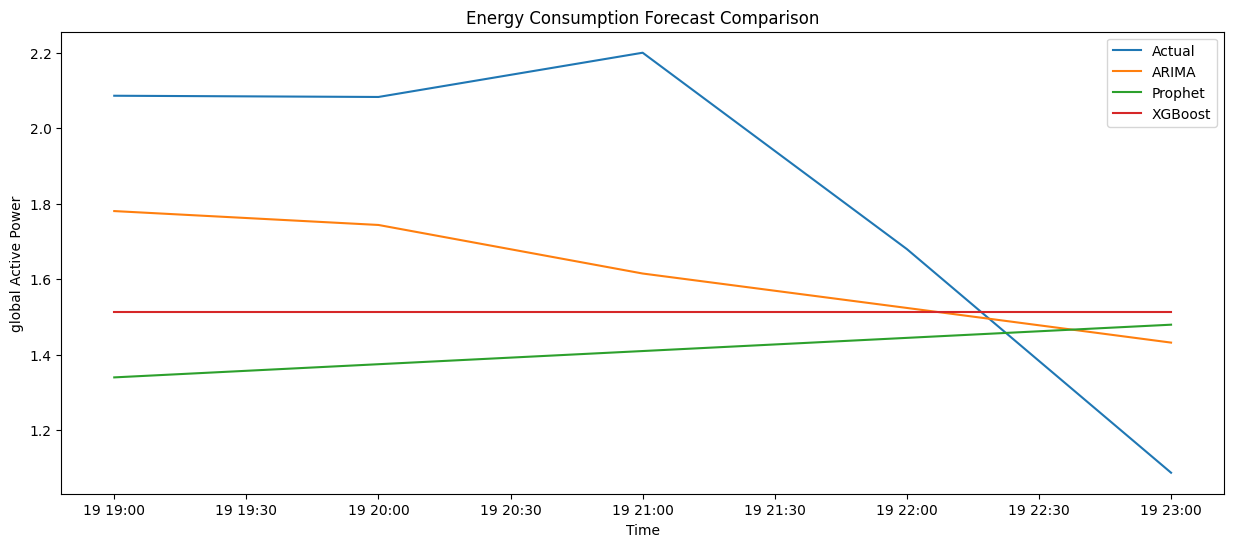

In [33]:
plt.figure(figsize=(15,6))

plt.plot(test.index, test['global_active_power'], label="Actual")

plt.plot(test.index, arima_pred, label="ARIMA")
plt.plot(test.index, prophet_pred, label="Prophet")
plt.plot(test.index, xgb_pred, label="XGBoost")

plt.legend()
plt.title("Energy Consumption Forecast Comparison")
plt.xlabel("Time")
plt.ylabel("global Active Power")
plt.show()
